## 3.7. Weight Decay

We can always mitigate overfitting by collecting more training data, but this is often costly or impossible. Assuming we have fixed data, we need tools to adjust our model's complexity. While we could limit the number of features, simply tossing aside features can be too blunt an instrument. 

Instead of directly manipulating the number of parameters, **weight decay** restricts the values that the parameters can take.

### 3.7.1. Norms and Weight Decay

Also known as $L_2$ regularization, weight decay might be the most widely used technique for regularizing machine learning models. The intuition is that the "simplest" function is one where all parameters are exactly zero. We measure complexity by the distance of the parameters from zero.

For linear regression, our original prediction loss was:
$$L(\mathbf{w}, b) = \frac{1}{n} \sum_{i=1}^n \frac{1}{2} \left( \mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)} \right)^2$$

To penalize large weights, we add the squared $L_2$ norm, $\|\mathbf{w}\|^2$, to the loss function, scaled by a regularization constant $\lambda$:
$$L(\mathbf{w}, b) + \frac{\lambda}{2} \|\mathbf{w}\|^2$$

By doing this, minibatch stochastic gradient descent updates the weights as follows:
$$\mathbf{w} \leftarrow (1 - \eta\lambda)\mathbf{w} - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \mathbf{x}^{(i)} \left( \mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)} \right)$$

This update specifically shrinks the size of $\mathbf{w}$ towards zero at each step, hence the name "weight decay".

### 3.7.2. High-Dimensional Linear Regression

We can illustrate the benefits of weight decay through a synthetic example where we deliberately overfit by using high dimensionality ($d = 200$) and a small training set (20 examples). Our label is generated by:
$$y = 0.05 + \sum_{i=1}^d 0.01 x_i + \epsilon \text{ where } \epsilon \sim \mathcal{N}(0, 0.01^2)$$

In [183]:
import torch
from torch.utils.data import TensorDataset,DataLoader
import matplotlib.pyplot as plt
torch.manual_seed(42)

#hyperpara
n_train,n_val,num_inputs,batch_size=20,200,120,5
true_w,true_b=torch.ones((num_inputs,1))*0.01,0.05

#generate training data
X_train=torch.randn(n_train,num_inputs)
y_train=torch.matmul(X_train,true_w)+true_b+torch.randn(n_train,1)*0.01
train_iter=DataLoader(TensorDataset(X_train,y_train),batch_size=batch_size,shuffle=True)

#generate validation data
X_val=torch.rand(n_val,num_inputs)
y_val=torch.matmul(X_val,true_w)+true_b+torch.randn(n_val,1)*0.01

### 3.7.3. Implementation from Scratch

Let's try implementing weight decay from scratch by adding the squared $L_2$ penalty to the original loss function.

#### 3.7.3.1. Defining $L_2$ Norm Penalty
The most convenient way to implement this penalty is to square all terms in place and sum them.

In [184]:
def l2_penalty(w):
    return (w**2).sum()/2

#### 3.7.3.2. Defining the Model
We define our standard linear regression model and our training loop. The only change to our standard workflow is that our loss calculation now includes the penalty term.

In [185]:
def linreg(X,w,b):
    return torch.matmul(X,w)+b

def squared_loss(y_hat,y):
    return (y_hat-y.reshape(y_hat.shape))**2/2

def sgd(params,lr,batch_size):
    with torch.no_grad():
        for param in params:
            param-=lr*param.grad/batch_size
            param.grad.zero_()

def train_scratch(lambd):
    w=torch.normal(0,0.01,size=(num_inputs,1),requires_grad=True)
    b=torch.zeros(1,requires_grad=True)
    epochs,lr=20,0.01
    train_losses,val_losses=[],[]

    for epoch in range(epochs):
        for X,y in train_iter:
            l=squared_loss(linreg(X,w,b),y)+lambd*l2_penalty(w)
            l.sum().backward()
            sgd([w,b],lr,batch_size)

        with torch.no_grad():
            train_losses.append(squared_loss(linreg(X_train,w,b),y_train).mean().item())
            val_losses.append(squared_loss(linreg(X_val,w,b),y_val).mean().item())
            
    print(f'L2 norm of w: {torch.norm(w).item():.5f}')
    
    plt.figure(figsize=(5, 3))
    plt.plot(range(1, epochs + 1), train_losses, label='train_loss')
    plt.plot(range(1, epochs + 1), val_losses, '--', label='val_loss')
    plt.yscale('log')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()
    plt.show()



#### 3.7.3.3. Training without Regularization
We now run this code with `lambd = 0`, disabling weight decay. Note that we overfit badly, decreasing the training error but not the validation error—a textbook case of overfitting.

L2 norm of w: 0.12267


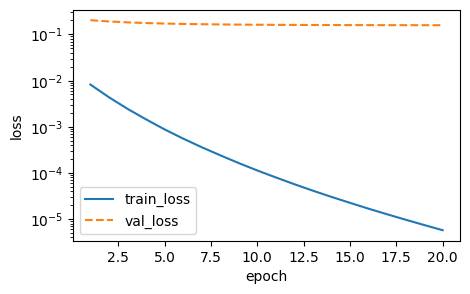

In [186]:
train_scratch(0)

#### 3.7.3.4. Using Weight Decay
Below, we run with substantial weight decay. Note that the training error increases but the validation error decreases. This is precisely the effect we expect from regularization.

L2 norm of w: 0.03068


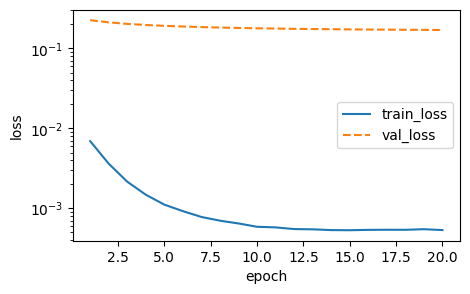

In [187]:
train_scratch(3)

### 3.7.4. Concise Implementation

Because weight decay is ubiquitous in neural network optimization, the deep learning framework makes it especially convenient. We specify the weight decay hyperparameter directly through `weight_decay` when instantiating our optimizer.

Here, we only set `weight_decay` for the weights, meaning the bias parameter will not decay.

L2 norm of w: 0.04847


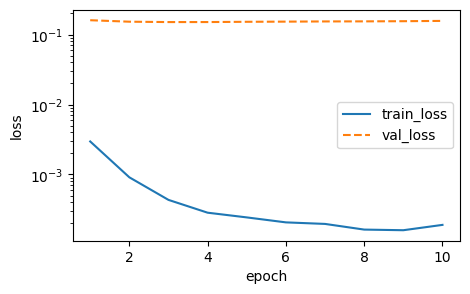

In [188]:
def train_concise(wd):
    #nn.linear(200,1) layer
    net=torch.nn.Sequential(torch.nn.Linear(num_inputs,1))

    for param in net.parameters():
        param.data.normal_(0,0.01)

    #built in mean squared error loss,reduction=0, means give loss for each sample, not mean
    loss=torch.nn.MSELoss(reduction='none')
    epochs,lr=10,0.01

    #configure sgd, only apply weight decay to w
    trainer=torch.optim.SGD([
        {"params":net[0].weight,'weight_decay':wd},
        {"params":net[0].bias}],lr=lr)
    train_losses,val_losses=[],[]

    for epoch in range(epochs):
        for X,y in train_iter:
            trainer.zero_grad()
            l=loss(net(X),y)
            l.mean().backward()
            #updates the weights automatically
            trainer.step()

        with torch.no_grad():
                train_losses.append(loss(net(X_train), y_train).mean().item() / 2)
                val_losses.append(loss(net(X_val), y_val).mean().item() / 2)
                
    print(f'L2 norm of w: {torch.norm(net[0].weight).item():.5f}')
    
    plt.figure(figsize=(5, 3))
    plt.plot(range(1, epochs + 1), train_losses, label='train_loss')
    plt.plot(range(1, epochs + 1), val_losses, '--', label='val_loss')
    plt.yscale('log')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()
    plt.show()

    
train_concise(3)

    
